In [ ]:
!unzip -q glenda_balanced.zip -d data



In [ ]:
import torch, numpy as np, random, os
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE")

IMG, BATCH = 224, 32
MEAN, STD = [0.485,0.456,0.406], [0.229,0.224,0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG,IMG)), transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(), transforms.Normalize(MEAN,STD)])
eval_tf = transforms.Compose([
    transforms.Resize((IMG,IMG)), transforms.ToTensor(), transforms.Normalize(MEAN,STD)])

train_ds = datasets.ImageFolder("data/train", train_tf)
val_ds   = datasets.ImageFolder("data/val",   eval_tf)
test_ds  = datasets.ImageFolder("data/test",  eval_tf)
train_dl = DataLoader(train_ds, BATCH, shuffle=True,  num_workers=2)
val_dl   = DataLoader(val_ds,   BATCH, shuffle=False, num_workers=2)
test_dl  = DataLoader(test_ds,  BATCH, shuffle=False, num_workers=2)

POS = train_ds.class_to_idx["endometriosis"]
print("class_to_idx:", train_ds.class_to_idx, "| POS:", POS)
print("Sizes -> train:",len(train_ds)," val:",len(val_ds)," test:",len(test_ds))

Device: cuda | GPU: Tesla T4
class_to_idx: {'endometriosis': 0, 'normal': 1} | POS: 0
Sizes -> train: 528  val: 111  test: 107


In [ ]:
import torch.nn as nn, copy
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score

def train_model(model, name, epochs=30, lr=1e-4, patience=6):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best_auc, best_state, wait = 0.0, None, 0
    for ep in range(epochs):
        model.train()
        for x,y in train_dl:
            x,y = x.to(device), y.to(device)
            opt.zero_grad(); crit(model(x), y).backward(); opt.step()
        model.eval(); probs, trues = [], []
        with torch.no_grad():
            for x,y in val_dl:
                p = torch.softmax(model(x.to(device)),1)[:,POS].cpu().numpy()
                probs += p.tolist(); trues += (y.numpy()==POS).astype(int).tolist()
        auc = roc_auc_score(trues, probs)
        f1  = f1_score(trues, [1 if p>=0.5 else 0 for p in probs])
        print(f"[{name}] epoch {ep+1:02d}  val_AUC={auc:.3f}  val_F1={f1:.3f}")
        if auc > best_auc: best_auc, best_state, wait = auc, copy.deepcopy(model.state_dict()), 0
        else:
            wait += 1
            if wait >= patience: print(f"  early stop @ epoch {ep+1}"); break
    model.load_state_dict(best_state)
    torch.save(best_state, f"best_{name}.pth")
    print(f"[{name}] BEST val AUC = {best_auc:.3f}  (saved best_{name}.pth)")
    return model

resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Linear(resnet.fc.in_features, 2)
resnet = train_model(resnet, "resnet50")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 48.8MB/s]


[resnet50] epoch 01  val_AUC=0.715  val_F1=0.587
[resnet50] epoch 02  val_AUC=0.844  val_F1=0.722
[resnet50] epoch 03  val_AUC=0.931  val_F1=0.831
[resnet50] epoch 04  val_AUC=0.919  val_F1=0.814
[resnet50] epoch 05  val_AUC=0.892  val_F1=0.779
[resnet50] epoch 06  val_AUC=0.870  val_F1=0.777
[resnet50] epoch 07  val_AUC=0.929  val_F1=0.797
[resnet50] epoch 08  val_AUC=0.939  val_F1=0.783
[resnet50] epoch 09  val_AUC=0.924  val_F1=0.780
[resnet50] epoch 10  val_AUC=0.897  val_F1=0.767
[resnet50] epoch 11  val_AUC=0.895  val_F1=0.788
[resnet50] epoch 12  val_AUC=0.907  val_F1=0.794
[resnet50] epoch 13  val_AUC=0.945  val_F1=0.753
[resnet50] epoch 14  val_AUC=0.937  val_F1=0.806
[resnet50] epoch 15  val_AUC=0.940  val_F1=0.783
[resnet50] epoch 16  val_AUC=0.941  val_F1=0.844
[resnet50] epoch 17  val_AUC=0.933  val_F1=0.850
[resnet50] epoch 18  val_AUC=0.937  val_F1=0.800
[resnet50] epoch 19  val_AUC=0.961  val_F1=0.829
[resnet50] epoch 20  val_AUC=0.959  val_F1=0.848
[resnet50] epoch 21 

In [7]:
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, 2)
effnet = train_model(effnet, "efficientnet_b0", lr=1e-4)

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
vit.heads.head = nn.Linear(vit.heads.head.in_features, 2)
vit = train_model(vit, "vit_b16", lr=2e-5)

[efficientnet_b0] epoch 01  val_AUC=0.763  val_F1=0.677
[efficientnet_b0] epoch 02  val_AUC=0.886  val_F1=0.769
[efficientnet_b0] epoch 03  val_AUC=0.907  val_F1=0.807
[efficientnet_b0] epoch 04  val_AUC=0.932  val_F1=0.855
[efficientnet_b0] epoch 05  val_AUC=0.941  val_F1=0.857
[efficientnet_b0] epoch 06  val_AUC=0.951  val_F1=0.810
[efficientnet_b0] epoch 07  val_AUC=0.962  val_F1=0.872
[efficientnet_b0] epoch 08  val_AUC=0.963  val_F1=0.836
[efficientnet_b0] epoch 09  val_AUC=0.962  val_F1=0.822
[efficientnet_b0] epoch 10  val_AUC=0.949  val_F1=0.831
[efficientnet_b0] epoch 11  val_AUC=0.958  val_F1=0.864
[efficientnet_b0] epoch 12  val_AUC=0.965  val_F1=0.897
[efficientnet_b0] epoch 13  val_AUC=0.969  val_F1=0.903
[efficientnet_b0] epoch 14  val_AUC=0.979  val_F1=0.955
[efficientnet_b0] epoch 15  val_AUC=0.975  val_F1=0.900
[efficientnet_b0] epoch 16  val_AUC=0.967  val_F1=0.788
[efficientnet_b0] epoch 17  val_AUC=0.970  val_F1=0.791
[efficientnet_b0] epoch 18  val_AUC=0.965  val_F

=== TEST-SET RESULTS ===
                 Accuracy  Precision  Recall      F1     AUC
ResNet50           0.8037     0.7286  0.9623  0.8293  0.9385
EfficientNet-B0    0.7664     0.7000  0.9245  0.7967  0.8270
ViT-B/16           0.7850     0.7206  0.9245  0.8099  0.9207


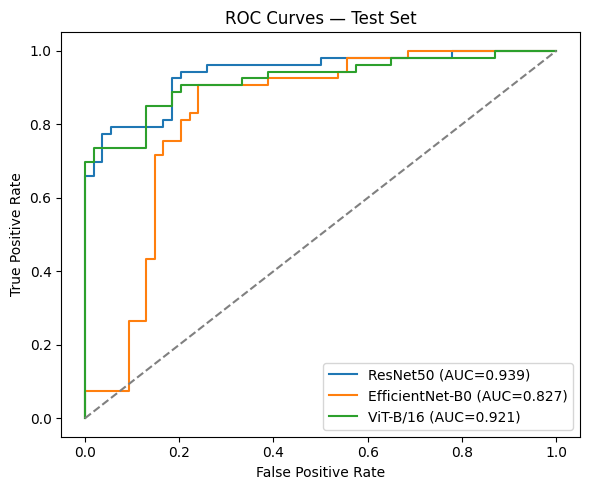

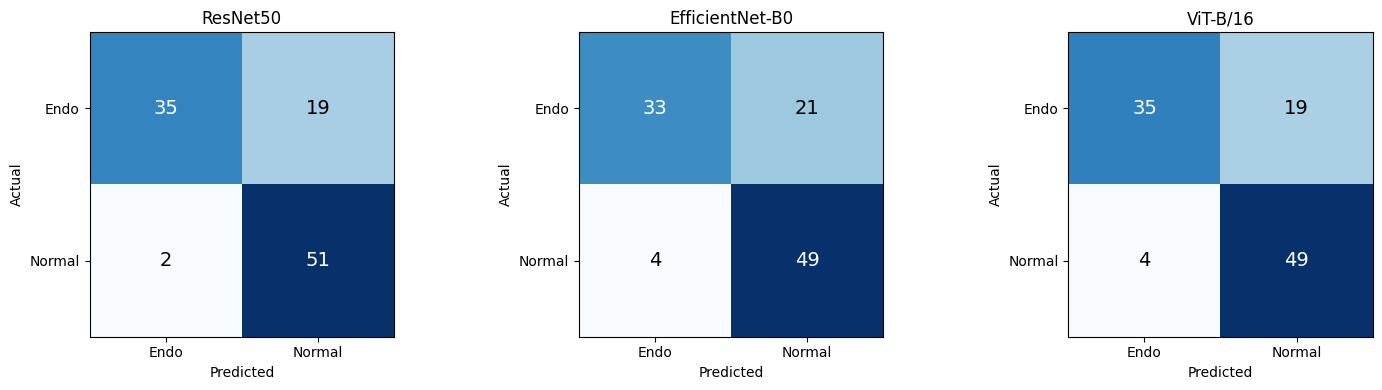

Done. Saved results.


In [9]:
import matplotlib.pyplot as plt, pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

MODELS = {"ResNet50": resnet, "EfficientNet-B0": effnet, "ViT-B/16": vit}

def evaluate(model):
    model.eval(); probs, trues = [], []
    with torch.no_grad():
        for x,y in test_dl:
            p = torch.softmax(model(x.to(device)),1)[:,POS].cpu().numpy()
            probs += p.tolist(); trues += (y.numpy()==POS).astype(int).tolist()
    probs, trues = np.array(probs), np.array(trues); preds=(probs>=0.5).astype(int)
    return dict(Accuracy=accuracy_score(trues,preds), Precision=precision_score(trues,preds),
                Recall=recall_score(trues,preds), F1=f1_score(trues,preds),
                AUC=roc_auc_score(trues,probs)), trues, probs, preds

results, roc_data, cms = {}, {}, {}
for name, m in MODELS.items():
    metrics, trues, probs, preds = evaluate(m)
    results[name]=metrics; roc_data[name]=(trues,probs); cms[name]=confusion_matrix(trues,preds)

df = pd.DataFrame(results).T.round(4)
print("=== TEST-SET RESULTS ==="); print(df); df.to_csv("test_results.csv")

plt.figure(figsize=(6,5))
for name,(t,p) in roc_data.items():
    fpr,tpr,_ = roc_curve(t,p); plt.plot(fpr,tpr,label=f"{name} (AUC={roc_auc_score(t,p):.3f})")
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set"); plt.legend(loc="lower right")
plt.tight_layout(); plt.savefig("roc_curves.png", dpi=200); plt.show()

fig, axes = plt.subplots(1,3,figsize=(15,4))
for ax,(name,cm) in zip(axes,cms.items()):
    ax.imshow(cm,cmap="Blues"); ax.set_title(name)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Endo","Normal"]); ax.set_yticklabels(["Endo","Normal"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    for i in range(2):
        for j in range(2):
            ax.text(j,i,cm[i,j],ha="center",va="center",
                    color="white" if cm[i,j]>cm.max()/2 else "black",fontsize=14)
plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=200); plt.show()

print("Done. Saved results.")